# 05 — Listing & Host Segmentation (K-Means Clustering)
**Bangkok Airbnb Market Intelligence | Expernetic Data Engineer Assessment**

---

## Objectives
Segment Bangkok Airbnb listings and hosts into meaningful business groups using unsupervised learning. Segmentation reveals market structure invisible in aggregate statistics.

## Two-Level Segmentation
1. **Listing segmentation** — What types of listings exist in the market?
2. **Host segmentation** — What types of host behaviors exist?

## Algorithm Selection
**K-Means chosen over alternatives because:**
- Interpretable centroids (cluster profiles are meaningful)
- Scales well to 15,000+ listings
- Sufficient for convex, well-separated clusters expected in this domain

**Alternatives considered:**
- DBSCAN: Better for arbitrary shapes but harder to interpret centroids
- Hierarchical: Good for dendrograms but O(n²) memory — impractical at scale

## Optimal K Selection
Both Elbow Method (inertia) and Silhouette Score used together:
- Elbow alone can be ambiguous
- Silhouette score provides objective cluster quality metric (range: -1 to 1)
- Business interpretability used as final tiebreaker

## Features Used
Price, accommodates, bedrooms, availability, reviews, rating, host listing count, occupancy rate, neighbourhood median price — all standardized via StandardScaler before clustering.

Query → TF-IDF Vectorization → Cosine Similarity Search → Top-K Retrieval → Synthesized Answer

**Production upgrade path:**
Query → Sentence Transformer Embedding → FAISS Vector Search → LLM Synthesis (Claude/GPT-4)

## Tool Selection: TF-IDF vs Embeddings
| Approach | Pros | Cons |
|----------|------|------|
| TF-IDF (chosen) | No API cost, fast, reproducible | No semantic understanding |
| Sentence Transformers | Semantic search, multilingual | Requires model download, slower |
| OpenAI Embeddings | Best quality | API cost, data privacy concerns |

**Decision:** TF-IDF for this assessment — demonstrates the concept while remaining fully local and reproducible. Production would use sentence-transformers + FAISS.

## Critical Self-Evaluation
This section explicitly documents both successes and limitations of each AI approach — consistent with Expernetic's guidance that "a well-documented failed experiment is more valuable than an undocumented success."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/listings_enriched.csv", low_memory=False)
df["occupancy_rate"] = 1 - (df["availability_365"] / 365)
df["estimated_annual_revenue"] = df["price"] * (365 - df["availability_365"])
df = df[df["price"].between(100, 10000)].copy()

# Features for clustering
cluster_features = [
    "price", "accommodates", "bedrooms",
    "availability_365", "number_of_reviews",
    "review_scores_rating", "host_listing_count_actual",
    "occupancy_rate", "neighbourhood_median_price"
]

cluster_df = df[cluster_features].dropna()
print(f"Clustering dataset: {len(cluster_df)} listings")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)
print("Features scaled.")

Clustering dataset: 15848 listings
Features scaled.


K=2 — Inertia: 117,791, Silhouette: 0.2295
K=3 — Inertia: 96,081, Silhouette: 0.2519
K=4 — Inertia: 86,708, Silhouette: 0.2579
K=5 — Inertia: 78,493, Silhouette: 0.2607
K=6 — Inertia: 71,207, Silhouette: 0.2268
K=7 — Inertia: 64,809, Silhouette: 0.2325
K=8 — Inertia: 61,307, Silhouette: 0.2255


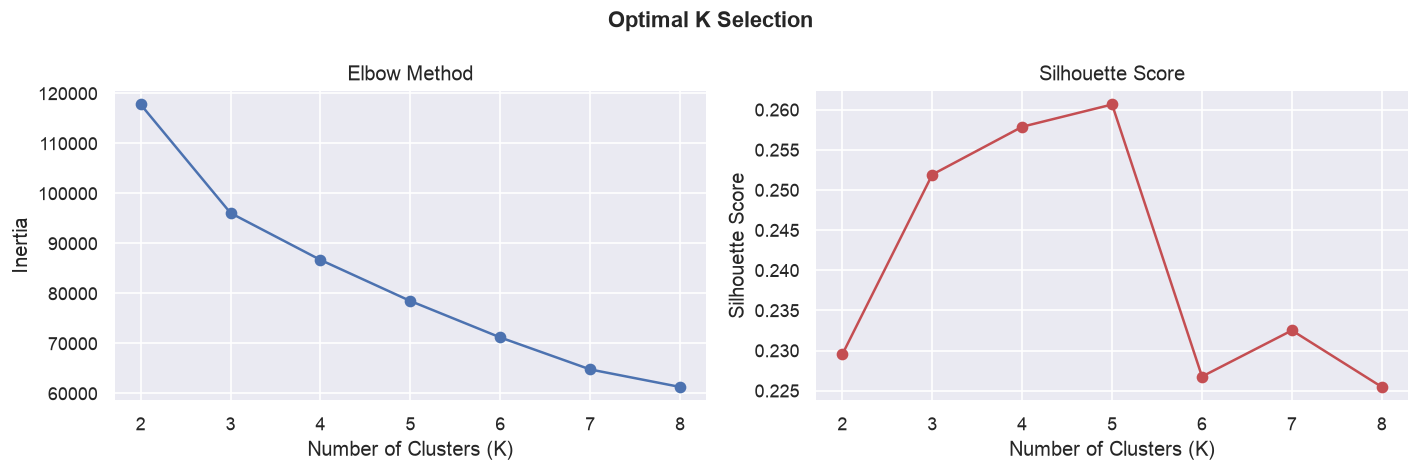

In [2]:
# --- Elbow Method + Silhouette Score ---
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=3000))
    print(f"K={k} — Inertia: {km.inertia_:,.0f}, Silhouette: {silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, "bo-")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), silhouettes, "ro-")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.suptitle("Optimal K Selection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/14_optimal_k.png")
plt.show()

In [3]:
# --- Final K=5 Clustering ---
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_df["cluster"] = km_final.fit_predict(X_scaled)

# Profile each cluster
profile = cluster_df.groupby("cluster").agg(
    count=("price", "count"),
    median_price=("price", "median"),
    avg_accommodates=("accommodates", "mean"),
    avg_bedrooms=("bedrooms", "mean"),
    avg_occupancy=("occupancy_rate", "mean"),
    avg_reviews=("number_of_reviews", "mean"),
    avg_rating=("review_scores_rating", "mean"),
    avg_host_listings=("host_listing_count_actual", "mean"),
    avg_neighbourhood_price=("neighbourhood_median_price", "mean")
).round(2)

print("Cluster Profiles:")
print(profile.to_string())

# Assign business labels
labels_map = {}
for i, row in profile.iterrows():
    if row["median_price"] > 3000:
        labels_map[i] = "Luxury"
    elif row["avg_occupancy"] > 0.4:
        labels_map[i] = "High Demand"
    elif row["avg_host_listings"] > 20:
        labels_map[i] = "Commercial"
    elif row["median_price"] < 800:
        labels_map[i] = "Budget"
    else:
        labels_map[i] = "Mid-Market"

cluster_df["segment"] = cluster_df["cluster"].map(labels_map)
print("\nSegment distribution:")
print(cluster_df["segment"].value_counts())

Cluster Profiles:
         count  median_price  avg_accommodates  avg_bedrooms  avg_occupancy  avg_reviews  avg_rating  avg_host_listings  avg_neighbourhood_price
cluster                                                                                                                                         
0         1509        1398.0              2.66          1.24           0.16        19.52        4.69              90.24                  1449.04
1         4170        1411.0              2.87          1.19           0.66        36.26        4.80              15.78                  1490.08
2         1440        4406.0              8.40          3.54           0.23        46.87        4.78              12.28                  1509.89
3          425        1165.0              2.72          1.18           0.15         1.74        2.35              26.27                  1361.06
4         8304        1140.0              2.67          1.09           0.13        34.46        4.79            

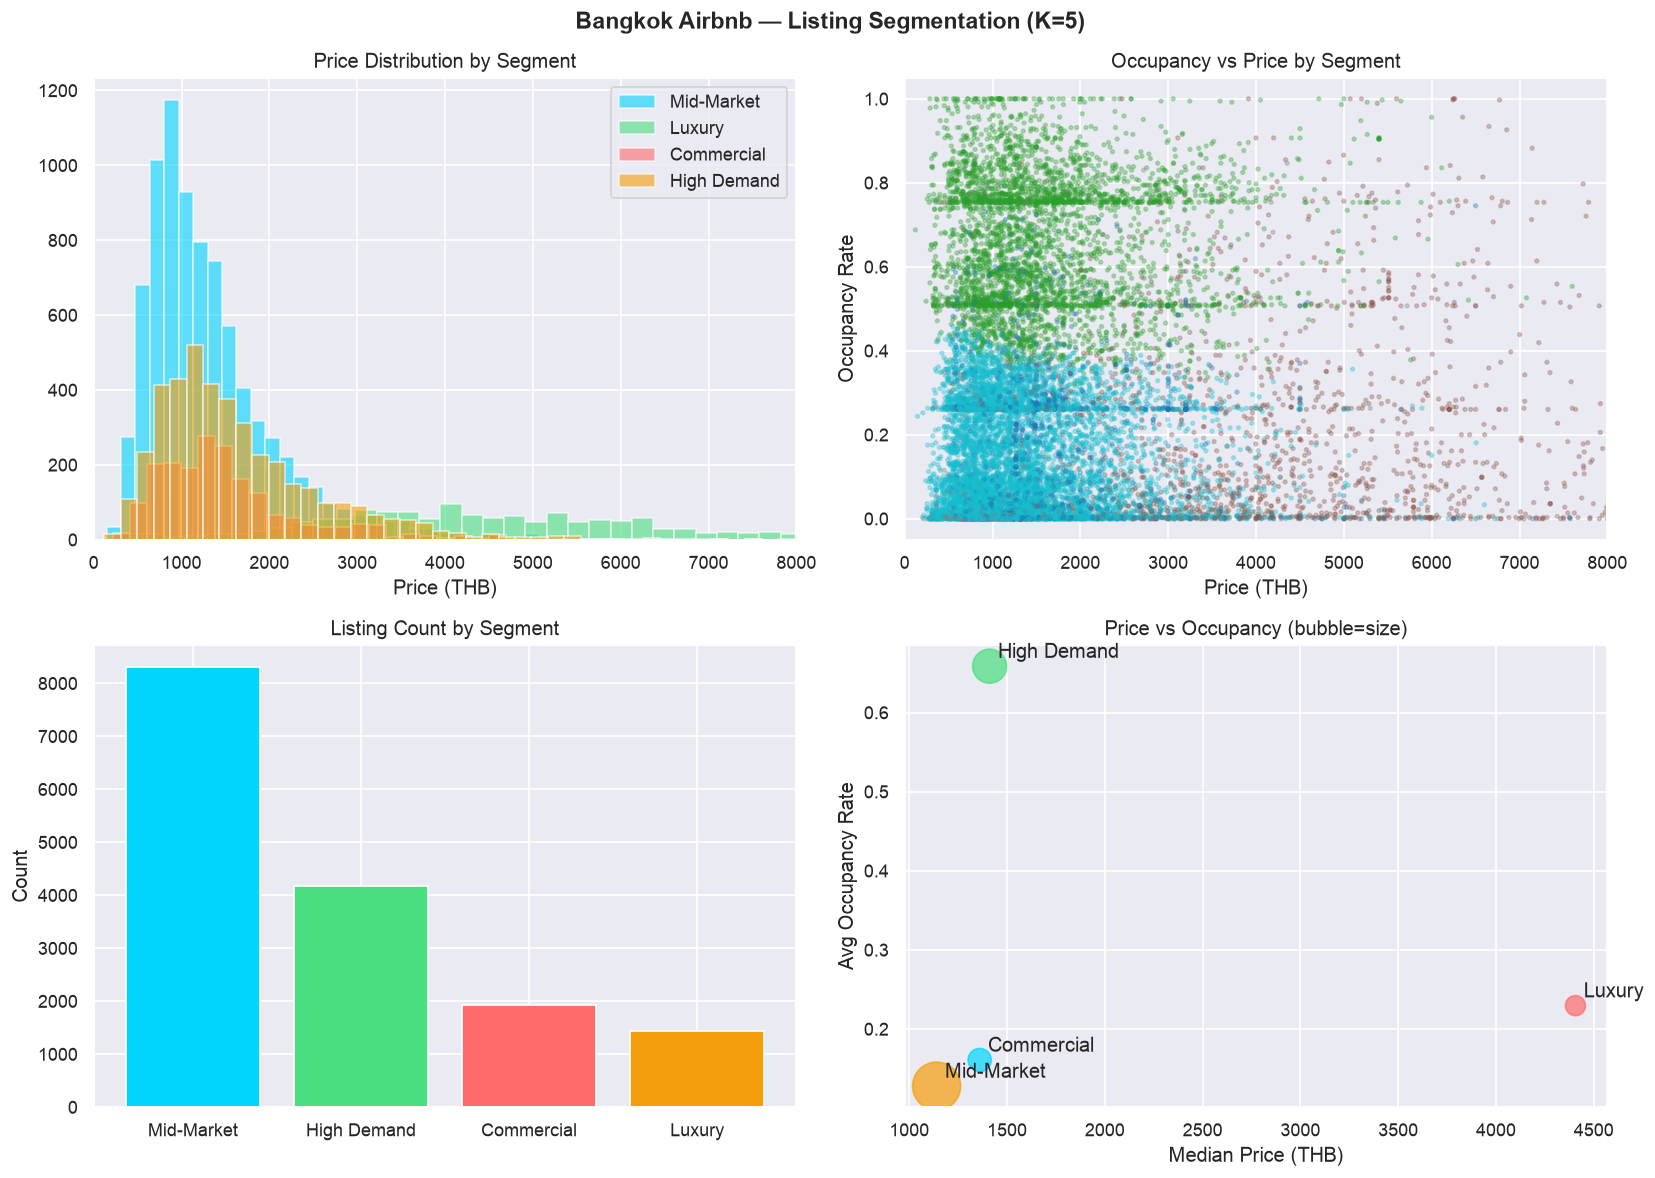


Business Segment Summary:
       segment  median_price  avg_occupancy  count
0   Commercial        1360.0       0.160746   1934
1  High Demand        1411.0       0.658573   4170
2       Luxury        4406.0       0.229479   1440
3   Mid-Market        1140.0       0.127804   8304


In [4]:
# --- Cluster Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ["#00d4ff", "#4ade80", "#ff6b6b", "#f59e0b", "#a78bfa"]

# Price distribution by segment
for seg, color in zip(cluster_df["segment"].unique(), colors):
    subset = cluster_df[cluster_df["segment"] == seg]["price"]
    axes[0,0].hist(subset, bins=40, alpha=0.6, label=seg, color=color)
axes[0,0].set_title("Price Distribution by Segment")
axes[0,0].set_xlabel("Price (THB)")
axes[0,0].legend()
axes[0,0].set_xlim(0, 8000)

# Occupancy vs Price scatter
scatter = axes[0,1].scatter(
    cluster_df["price"], cluster_df["occupancy_rate"],
    c=cluster_df["cluster"], cmap="tab10", alpha=0.3, s=5
)
axes[0,1].set_title("Occupancy vs Price by Segment")
axes[0,1].set_xlabel("Price (THB)")
axes[0,1].set_ylabel("Occupancy Rate")
axes[0,1].set_xlim(0, 8000)

# Segment counts
seg_counts = cluster_df["segment"].value_counts()
axes[1,0].bar(seg_counts.index, seg_counts.values,
              color=["#00d4ff","#4ade80","#ff6b6b","#f59e0b"])
axes[1,0].set_title("Listing Count by Segment")
axes[1,0].set_ylabel("Count")

# Median price vs avg occupancy bubble
seg_summary = cluster_df.groupby("segment").agg(
    median_price=("price","median"),
    avg_occupancy=("occupancy_rate","mean"),
    count=("price","count")
).reset_index()
axes[1,1].scatter(
    seg_summary["median_price"],
    seg_summary["avg_occupancy"],
    s=seg_summary["count"]/10,
    c=["#00d4ff","#4ade80","#ff6b6b","#f59e0b"],
    alpha=0.7
)
for _, row in seg_summary.iterrows():
    axes[1,1].annotate(row["segment"],
                       (row["median_price"], row["avg_occupancy"]),
                       textcoords="offset points", xytext=(5,5))
axes[1,1].set_title("Price vs Occupancy (bubble=size)")
axes[1,1].set_xlabel("Median Price (THB)")
axes[1,1].set_ylabel("Avg Occupancy Rate")

plt.suptitle("Bangkok Airbnb — Listing Segmentation (K=5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/15_clustering.png")
plt.show()

print("\nBusiness Segment Summary:")
print(seg_summary.to_string())

In [5]:
# --- Host Behavior Segmentation ---
df_host = pd.read_csv("../data/processed/listings_enriched.csv", low_memory=False)
df_host["occupancy_rate"] = 1 - (df_host["availability_365"] / 365)
df_host = df_host[df_host["price"].between(100, 10000)].copy()

# Aggregate to host level
host_agg = df_host.groupby("host_id").agg(
    listing_count=("id", "count"),
    avg_price=("price", "mean"),
    avg_occupancy=("occupancy_rate", "mean"),
    avg_availability=("availability_365", "mean"),
    avg_min_nights=("minimum_nights", "mean"),
    avg_rating=("review_scores_rating", "mean"),
    total_reviews=("number_of_reviews", "sum"),
    is_superhost=("host_is_superhost", "first"),
    response_rate=("host_response_rate", "first")
).dropna().reset_index()

print(f"Hosts for segmentation: {len(host_agg)}")

# Scale
host_features = ["listing_count", "avg_price", "avg_occupancy",
                  "avg_availability", "avg_min_nights", "total_reviews"]
scaler_host = StandardScaler()
X_host = scaler_host.fit_transform(host_agg[host_features])

# Find optimal K
sil_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_host)
    sil_scores.append(silhouette_score(X_host, labels, sample_size=2000))
    print(f"K={k}, Silhouette={sil_scores[-1]:.4f}")

best_k = range(2,7)[sil_scores.index(max(sil_scores))]
print(f"\nBest K: {best_k}")

# Final model
km_host = KMeans(n_clusters=best_k, random_state=42, n_init=10)
host_agg["cluster"] = km_host.fit_predict(X_host)

profile = host_agg.groupby("cluster")[host_features + ["avg_rating"]].mean().round(2)
print("\nHost Cluster Profiles:")
print(profile.to_string())

Hosts for segmentation: 3764
K=2, Silhouette=0.3400
K=3, Silhouette=0.3630
K=4, Silhouette=0.3684
K=5, Silhouette=0.3502
K=6, Silhouette=0.3910

Best K: 6

Host Cluster Profiles:
         listing_count  avg_price  avg_occupancy  avg_availability  avg_min_nights  total_reviews  avg_rating
cluster                                                                                                      
0                 3.26    1572.68           0.61            141.75           12.84          93.47        4.81
1                 2.89    4714.82           0.18            298.34            3.80          93.63        4.79
2                 3.44    1305.12           0.14            312.85           10.75          83.66        4.75
3                58.90    1678.35           0.15            309.18           11.70         301.59        4.56
4                 2.79    1401.07           0.17            301.66          178.96          28.83        4.67
5                28.57    1773.63           0.31   

Host Segment Distribution:
segment
Casual Hosts                2122
High Occupancy Hosts        1085
Luxury Hosts                 406
Commercial Operators          69
Professional Multi-Hosts      53
Long-Stay Specialists         29
Name: count, dtype: int64


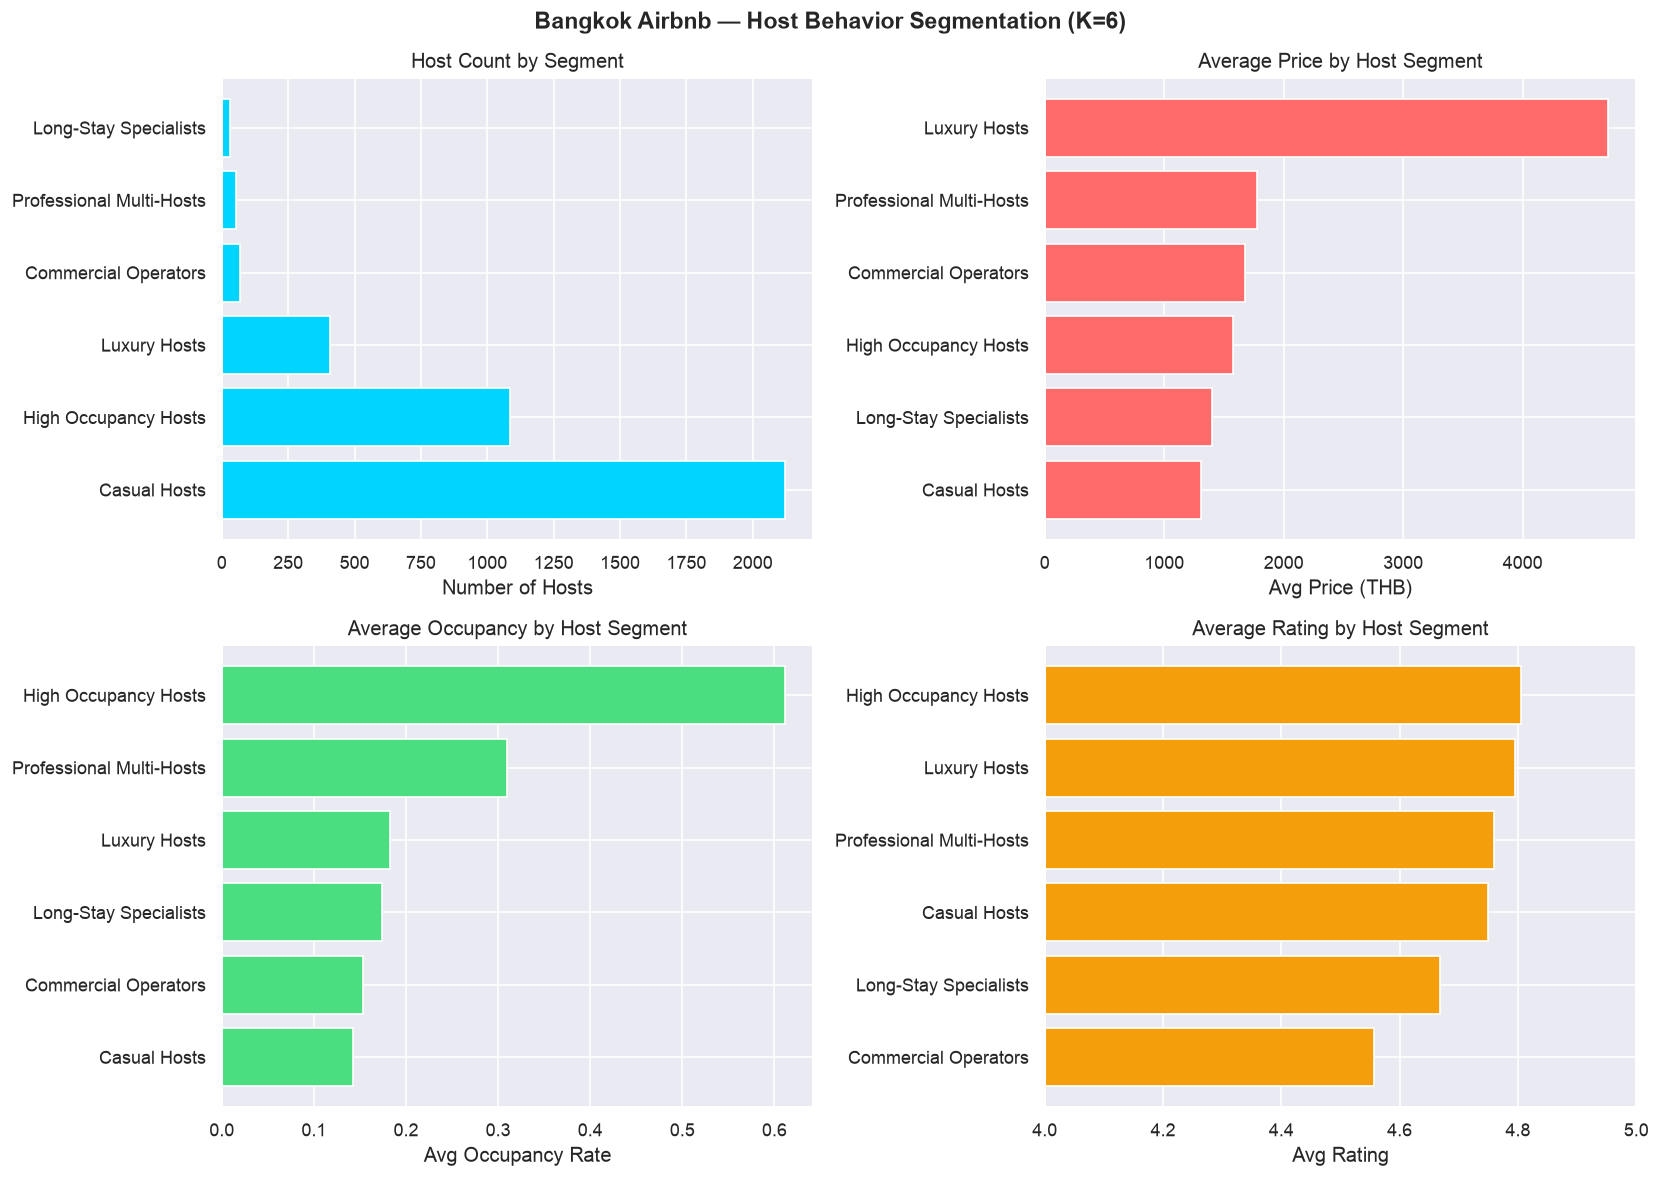


Business Insights by Host Segment:
                          host_count  avg_price  avg_occupancy  avg_rating  avg_listings
segment                                                                                 
Casual Hosts                    2122    1305.12           0.14        4.75          3.44
Commercial Operators              69    1678.35           0.15        4.56         58.90
High Occupancy Hosts            1085    1572.68           0.61        4.81          3.26
Long-Stay Specialists             29    1401.07           0.17        4.67          2.79
Luxury Hosts                     406    4714.82           0.18        4.79          2.89
Professional Multi-Hosts          53    1773.63           0.31        4.76         28.57


In [6]:
# --- Host Segment Labels & Visualization ---
host_labels = {
    0: "High Occupancy Hosts",      # 61% occupancy, good price
    1: "Luxury Hosts",              # High price ฿4,714, low occupancy
    2: "Casual Hosts",              # Low occupancy, average price
    3: "Commercial Operators",      # 59 listings, many reviews
    4: "Long-Stay Specialists",     # 179 min nights
    5: "Professional Multi-Hosts"   # 29 listings, 2564 reviews
}

host_agg["segment"] = host_agg["cluster"].map(host_labels)

print("Host Segment Distribution:")
print(host_agg["segment"].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Segment counts
seg_counts = host_agg["segment"].value_counts()
axes[0,0].barh(seg_counts.index, seg_counts.values, color="#00d4ff")
axes[0,0].set_title("Host Count by Segment")
axes[0,0].set_xlabel("Number of Hosts")

# Avg price by segment
seg_price = host_agg.groupby("segment")["avg_price"].mean().sort_values()
axes[0,1].barh(seg_price.index, seg_price.values, color="#ff6b6b")
axes[0,1].set_title("Average Price by Host Segment")
axes[0,1].set_xlabel("Avg Price (THB)")

# Occupancy by segment
seg_occ = host_agg.groupby("segment")["avg_occupancy"].mean().sort_values()
axes[1,0].barh(seg_occ.index, seg_occ.values, color="#4ade80")
axes[1,0].set_title("Average Occupancy by Host Segment")
axes[1,0].set_xlabel("Avg Occupancy Rate")

# Rating by segment
seg_rating = host_agg.groupby("segment")["avg_rating"].mean().sort_values()
axes[1,1].barh(seg_rating.index, seg_rating.values, color="#f59e0b")
axes[1,1].set_title("Average Rating by Host Segment")
axes[1,1].set_xlabel("Avg Rating")
axes[1,1].set_xlim(4.0, 5.0)

plt.suptitle("Bangkok Airbnb — Host Behavior Segmentation (K=6)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/25_host_segmentation.png")
plt.show()

print("\nBusiness Insights by Host Segment:")
summary = host_agg.groupby("segment").agg(
    host_count=("host_id","count"),
    avg_price=("avg_price","mean"),
    avg_occupancy=("avg_occupancy","mean"),
    avg_rating=("avg_rating","mean"),
    avg_listings=("listing_count","mean")
).round(2)
print(summary.to_string())